# Dataset Characterization

the idea of this notebook is to characterize the dataset only, regarding only structures dft data, maybe composition , ternary plot, and this kind of things.

input: `CuratedBriefSummary.pkl` 

output: plots

In [ ]:
from Tools.DatasetTools.Commoms import *
dataset = 'Fe-M'  # 'Cr-Co-W'#'Fe-Mo
target_case = 'EF_nmhcp'
components = dataset.split('-')
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer  import Featurizer
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('font', size=22)
plt.rc('text', usetex=True)


In [2]:
BSfile = os.path.join(dataset,'CuratedParsedBriefSummary.pkl' )
BS = pd.read_pickle(BSfile)

# Compositions 

# Population of phases

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


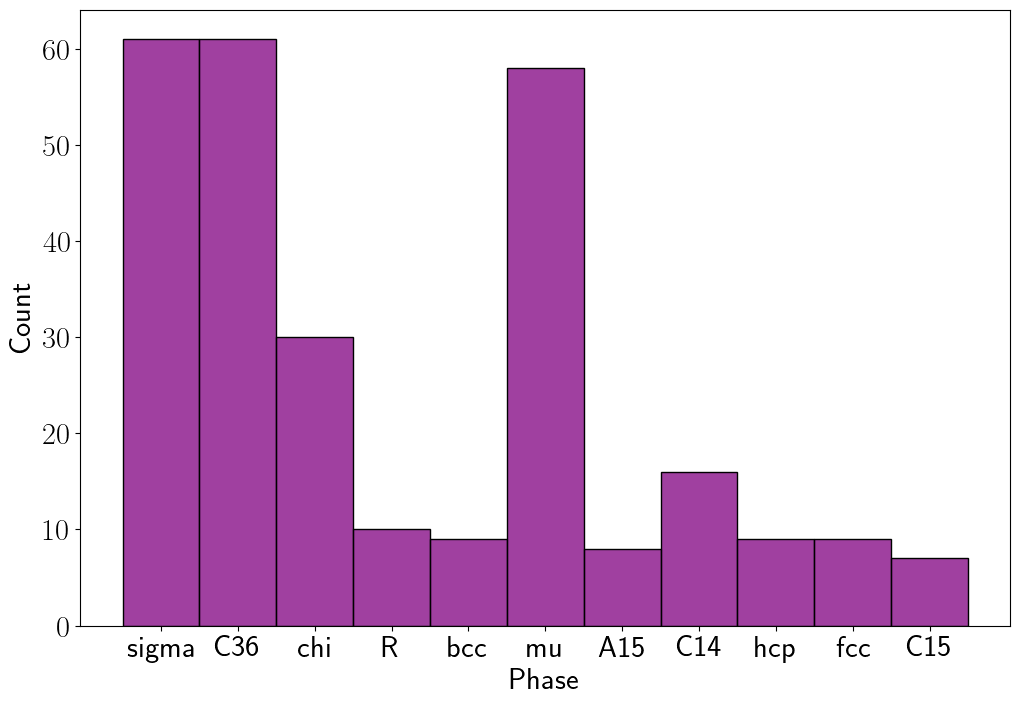

In [3]:
fig, ax = plt.subplots(figsize=(12,8))#, figsize=(12,8))
# sns.histplot(x = BS['Phase'], ax=ax)
#ax.hist(BS['Phase'])
ax = sns.histplot(x=BS['Phase'][BS['Phase']!='delta'], ax=ax, color='purple')
fig.savefig(f'{dataset}/graphs/{dataset}_ClassCounts.eps')
fig.savefig(f'{dataset}/graphs/{dataset}_ClassCounts.pdf')

In [4]:
BS['Phase'].value_counts()

sigma    61
C36      61
mu       58
chi      30
C14      16
R        10
bcc       9
hcp       9
fcc       9
A15       8
C15       7
delta     1
Name: Phase, dtype: int64

## Remove samples with very little representation

In [5]:
BS = BS[BS['Phase'] != 'delta']

# Extra features 

In [6]:
Features = Featurizer(BS)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


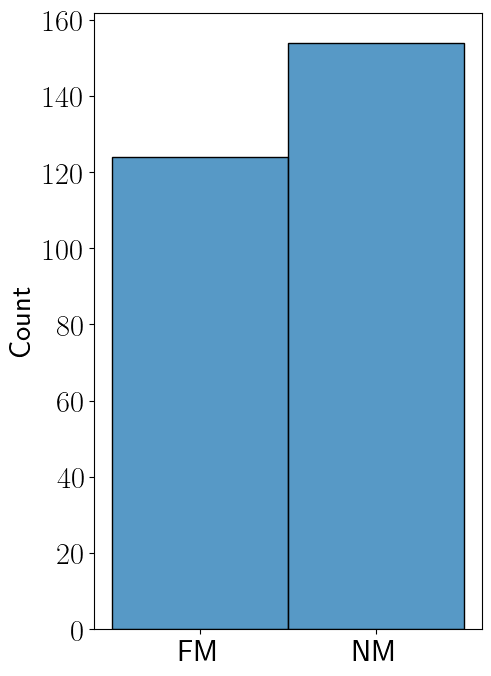

In [7]:
fig, ax = plt.subplots(figsize=(5,8))
sns.histplot(x = Features.Mag, ax=ax)
fig.savefig(f'{dataset}/graphs/{dataset}_FM_NM_counts.eps')

In [8]:
isfm = Features.Mag.str.contains('FM')

In [9]:
fmsamples = BS.index[isfm]

In [10]:
fmsamplesasnm = fmsamples.str.replace('.FM$','.NM')

In [11]:
nmsamples = BS.index[~isfm]

## fm samples without nm counterpart:

In [12]:
nmsamples.difference(fmsamplesasnm)

Index(['Fe_pv10Mo_sv14.C36-ABBBA.NM', 'Fe_pv10Mo_sv14.C36-BABAB.NM',
       'Fe_pv11Mo_sv2.mu-AAABA.NM', 'Fe_pv11Mo_sv2.mu-AABAA.NM',
       'Fe_pv13.mu.NM', 'Fe_pv13Mo_sv16.chi-ABAB.NM',
       'Fe_pv14Mo_sv16.sigma-AABAB.NM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv18Mo_sv6.C36-AAABA.NM', 'Fe_pv1Mo_sv1.L10-NiAl-AB.NM',
       'Fe_pv1Mo_sv3.D03-AB3.NM', 'Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM',
       'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM', 'Fe_pv28Mo_sv1.chi-BAAA.NM',
       'Fe_pv2Mo_sv11.mu-BBBBA.NM', 'Fe_pv2Mo_sv2.B32-AB.NM',
       'Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM', 'Fe_pv37Mo_sv14.R-AAAAAAAABBB.NM',
       'Fe_pv3Mo_sv1.D03-A3B.NM', 'Fe_pv3Mo_sv10.mu-ABBBA.NM',
       'Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM', 'Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM',
       'Fe_pv4Mo_sv26.sigma-BABBB.NM', 'Fe_pv53.R.NM',
       'Fe_pv5Mo_sv8.mu-ABBAA.NM', 'Fe_pv6.C15.NM',
       'Fe_pv6Mo_sv2.D0_19-A3B.NM', 'Fe_pv6Mo_sv24.sigma-AABBB.NM',
       'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM', 'Mo_sv53.R.NM'],
      dtype='object

## nm samples as without fm counterpart:

In [13]:
fmsamplesasnm.difference(nmsamples)

Index([], dtype='object')

# FM vs NM energies

#  Obvious outliers removal

In [14]:
BS = BS[(BS.B0 > 0 ) ]

In [15]:
minB0 = BS[BS['nelem']==1]['B0'].min()

In [16]:
maxB0 = BS[BS['nelem']==1]['B0'].max()

In [17]:
BS[BS['B0']>maxB0]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_nmhcp,EF_nmfcc,EF_fmbcc,Phase


In [18]:
BS[BS['B0']<minB0]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_nmhcp,EF_nmfcc,EF_fmbcc,Phase


# Distribution of Target Variables 

## total energy

In [19]:
targets = {'E0':r'$E_0$', 'B0':r'$B_0$', 'V0':r'$V_0$'}

some obvious outliers:

In [20]:
if dataset == 'Cr-Co-W':
    BS = BS[(BS['E0']>-500) & (BS['V0']<40)]

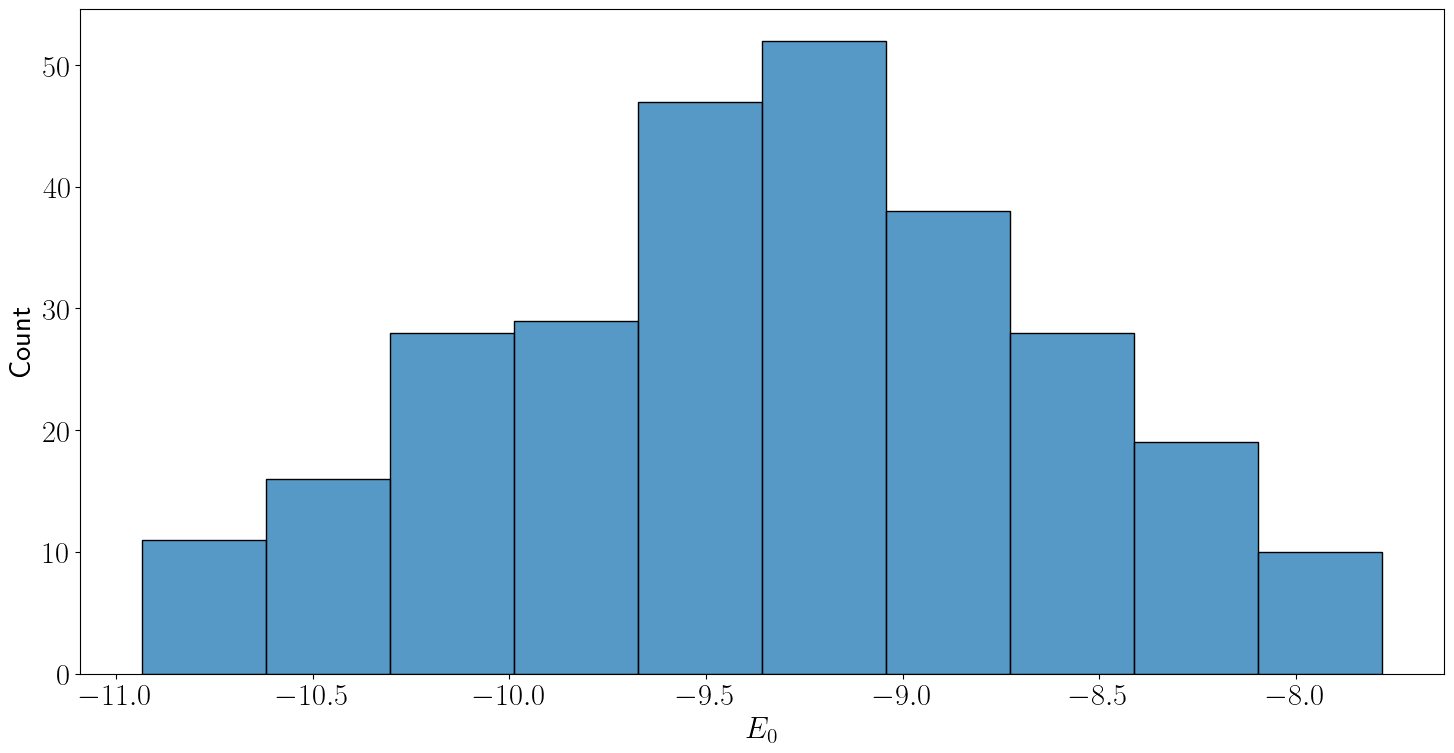

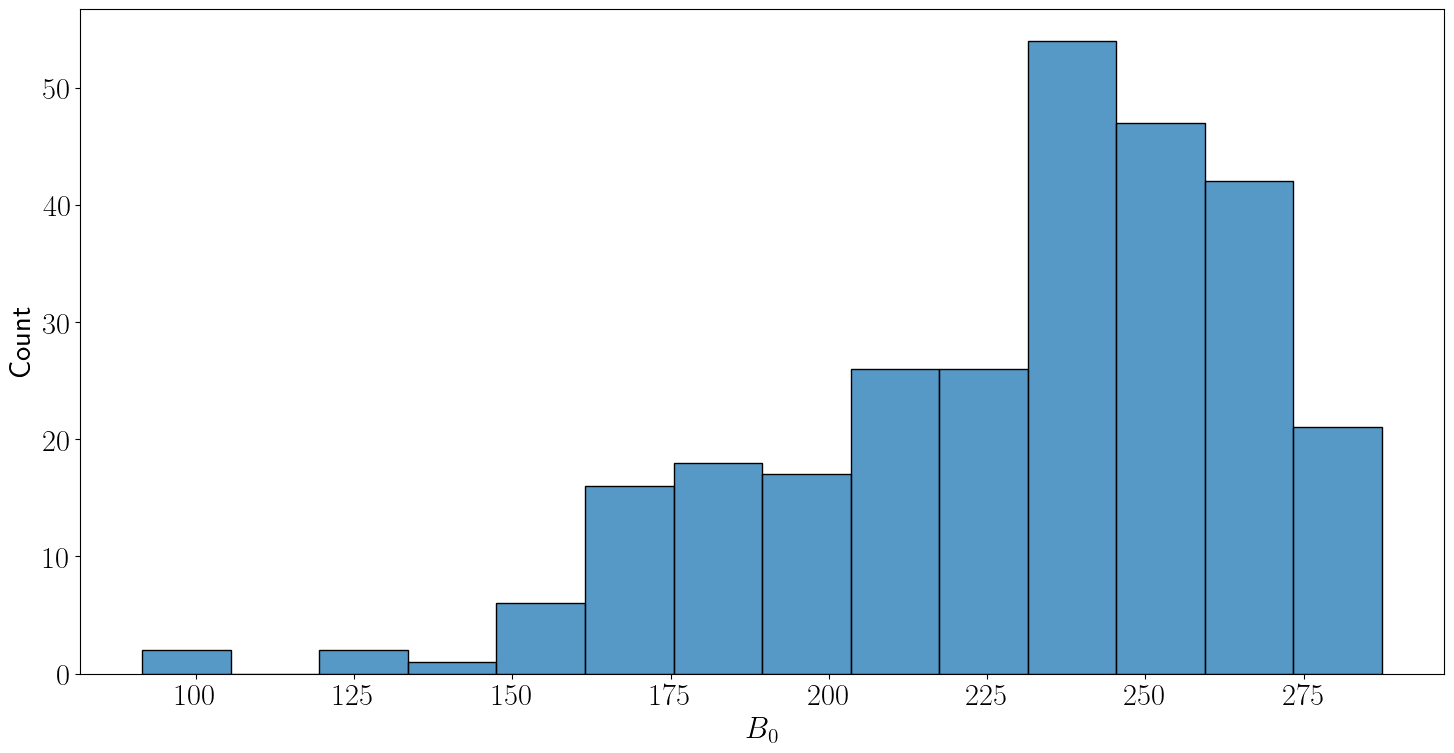

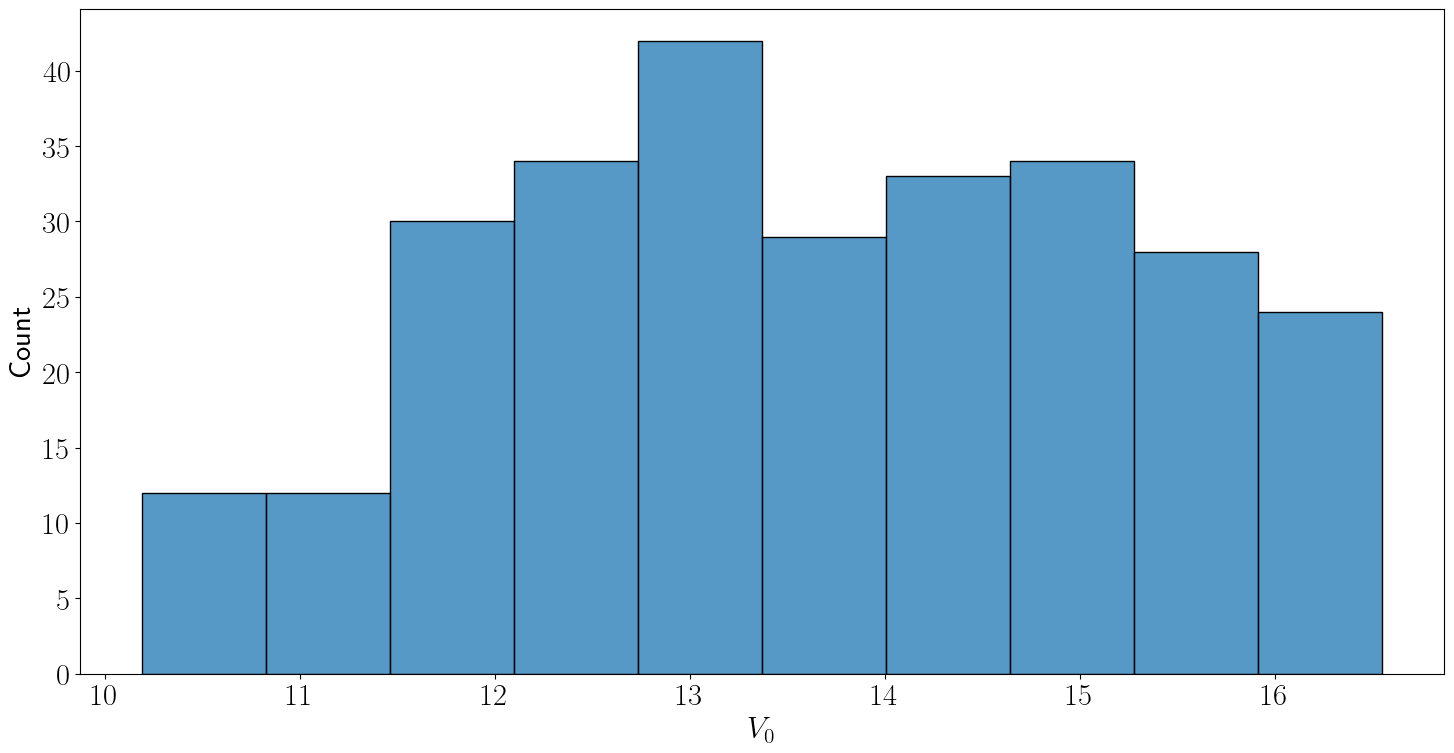

In [21]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# General correlation

In [22]:
BS.sort_values(by='B0', inplace=True)

In [23]:
target_case = 'EF_nmhcp'

In [24]:
targets[target_case] = '$\\Delta E_f$'

In [25]:
target

'V0'

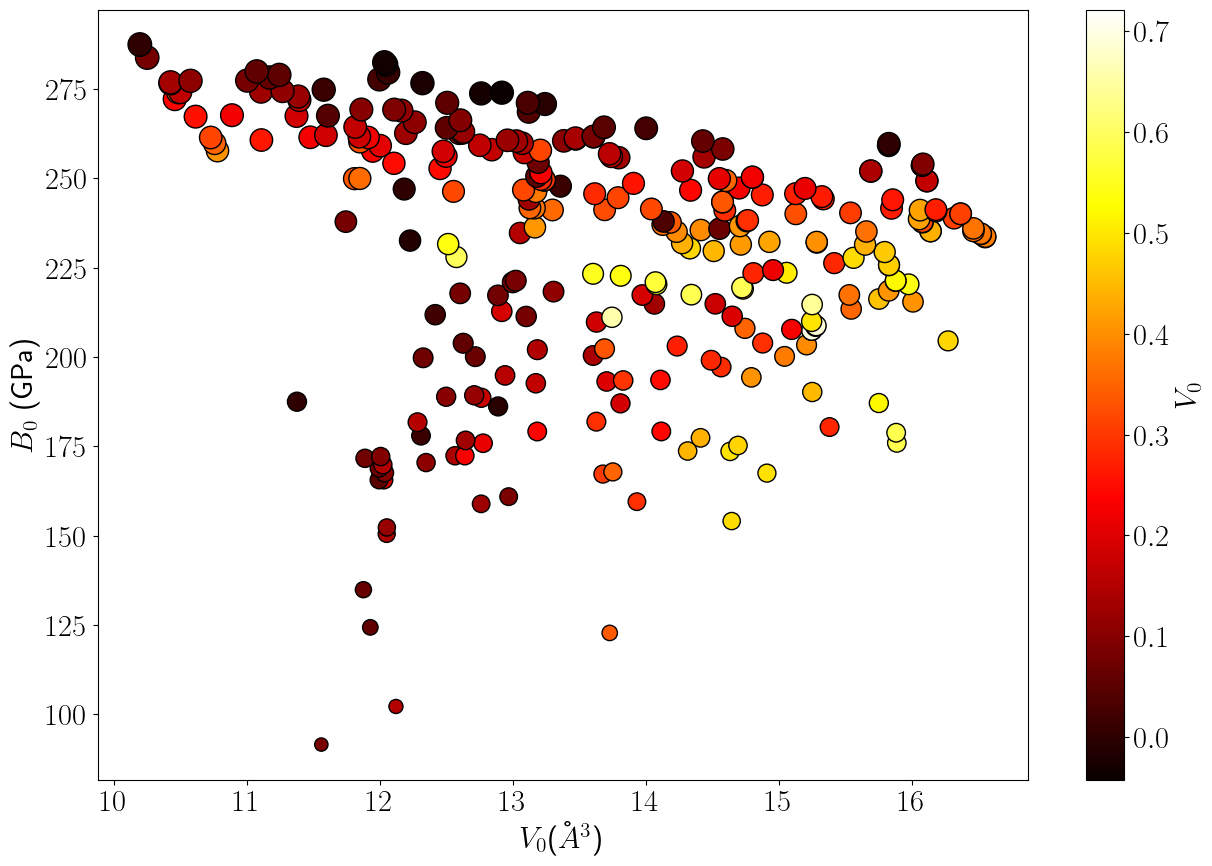

In [26]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.B0, c=BS[target_case], marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(targets['B0']+' (GPa)')
plt.xlabel(targets['V0']+'($\\AA^3$)')
cbar.set_label(targets[target])
#outlier_right = BS[(BS['E0']>-8) & (BS['V0']>14)].index
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )
#plt.annotate(outlier_right[0],*BS.loc[outlier_right][['V0', 'E0']].values,fontsize=16)
#outlier_high_b0 = BS[BS['B0']>1200].index
# plt.annotate(outlier_high_b0[0],*BS.loc[outlier_high_b0][['V0', 'E0']].values, fontsize=16)

from the plots below, we only would put in the paper the one with _V_0 in x, E_0 in y and B_0 in color coding_

# Pair Plots

In [27]:
ToPlot = BS[list(targets.keys())] #+['Phase']]
ToPlot.columns = list(targets.values()) #+['Phase']

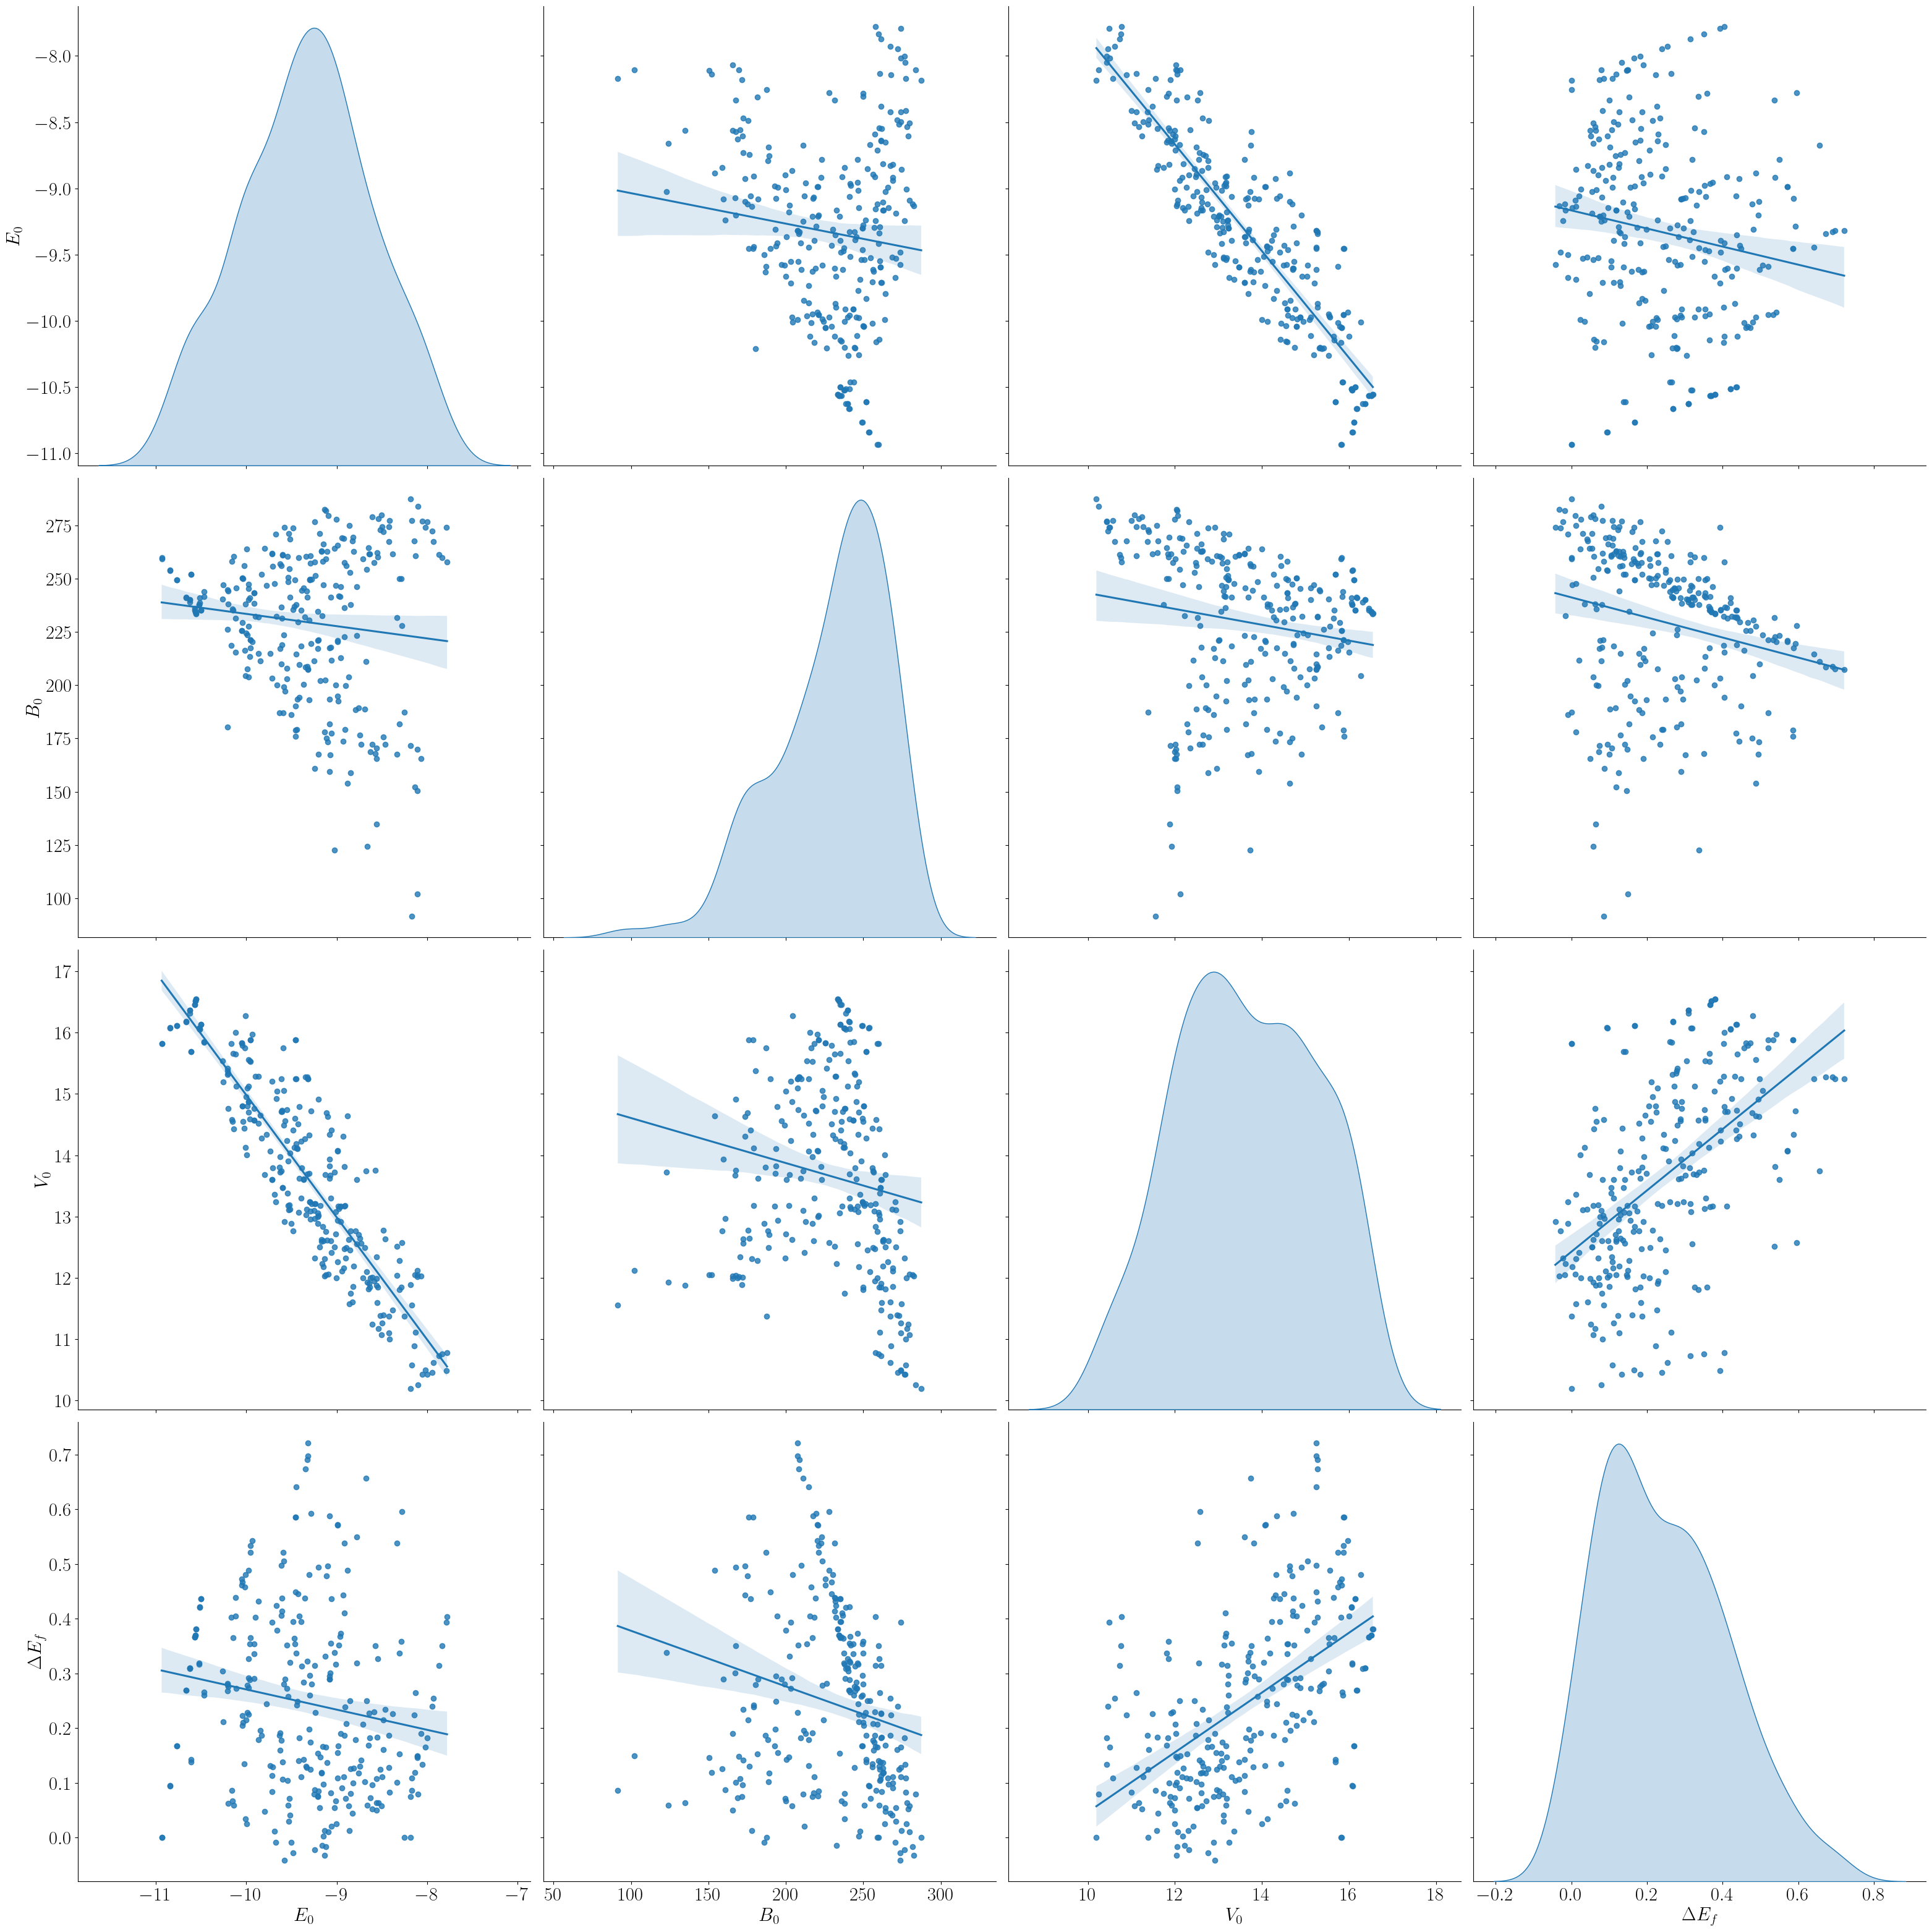

In [28]:
axis_grid = sns.pairplot(ToPlot, diag_kind = 'kde', kind='reg', height=8)
#, hue='Phase', x_vars=list(targets.values()), y_vars=list(targets.values()), )

# Magnetic vs Non Magnetic

In [29]:
EFFM = BS[target_case][Features.Mag == 'FM']

In [30]:
EFNMfcc = BS['EF_nmfcc'][Features.Mag == 'NM']

In [31]:
EFNMhcp = BS['EF_nmhcp'][Features.Mag == 'NM']

In [32]:
EFFM.index = EFFM.index.str.replace('.FM', '')

In [33]:
EFNMhcp.index = EFNMhcp.index.str.replace('.NM', '')

In [34]:
EFNMhcp.index = EFNMhcp.index.str.replace('.NM', '')

In [35]:
DE_mag  = EFNMhcp - EFFM 

In [36]:
DE_mag[ abs(DE_mag > 0.1)]

Fe_pv1.bcc                   0.393396
Fe_pv10Mo_sv2.C14-ABA        0.121951
Fe_pv10Mo_sv3.mu-BAAAB       0.111501
Fe_pv11Mo_sv2.mu-AAAAB       0.118357
Fe_pv12.C14                  0.164841
Fe_pv12Mo_sv1.mu-BAAAA       0.111115
Fe_pv14Mo_sv10.C36-AABAB     0.168965
Fe_pv14Mo_sv10.C36-AABBA     0.106243
Fe_pv18Mo_sv6.C36-AAAAB      0.244360
Fe_pv1Mo_sv1.B2-AB           0.132907
Fe_pv20Mo_sv4.C36-AABAA      0.124369
Fe_pv24.C36                  0.204949
Fe_pv28Mo_sv2.sigma-BAAAA    0.123198
Fe_pv30.sigma                0.107856
Fe_pv4Mo_sv9.mu-BBAAB        0.120165
Fe_pv5Mo_sv8.mu-ABAAB        0.143192
Fe_pv6Mo_sv2.A15-AB          0.169993
Fe_pv7Mo_sv6.mu-ABAAA        0.101912
Fe_pv8.A15                   0.154134
Fe_pv8Mo_sv16.C36-AABBB      0.105233
Name: EF_nmhcp, dtype: float64

In [37]:
DE_mag[DE_mag < 0 ]

Fe_pv10Mo_sv14.C36-BBAAB     -0.014172
Fe_pv10Mo_sv14.C36-BBABA     -0.027213
Fe_pv10Mo_sv20.sigma-ABBAB   -0.009879
Fe_pv12Mo_sv12.C36-BBBAA     -0.029583
Fe_pv12Mo_sv17.chi-BBAB      -0.015647
Fe_pv12Mo_sv17.chi-BBBA      -0.029450
Fe_pv12Mo_sv18.sigma-BABAB   -0.001992
Fe_pv13Mo_sv16.chi-ABBA      -0.031924
Fe_pv16Mo_sv13.chi-BABA      -0.002927
Fe_pv16Mo_sv8.C36-BBAAA      -0.018901
Fe_pv1Mo_sv1.hcp-AB          -0.035592
Fe_pv1Mo_sv12.mu-ABBBB       -0.005391
Fe_pv1Mo_sv28.chi-ABBB       -0.002428
Fe_pv2.hcp                   -0.189664
Fe_pv24Mo_sv5.chi-BBAA       -0.006320
Fe_pv25Mo_sv4.chi-ABAA       -0.006054
Fe_pv2Mo_sv10.C14-BAB        -0.011312
Fe_pv2Mo_sv11.mu-BBBAB       -0.010931
Fe_pv2Mo_sv28.sigma-ABBBB    -0.004718
Fe_pv2Mo_sv6.D0_19-AB3       -0.017782
Fe_pv3Mo_sv1.L12-A3B         -0.036506
Fe_pv4.fcc-cubic             -0.069194
Fe_pv4Mo_sv2.C15-A2B         -0.003125
Fe_pv4Mo_sv20.C36-BABBB      -0.011848
Fe_pv4Mo_sv20.C36-BBABB      -0.004633
Fe_pv4Mo_sv8.C14-ABB     

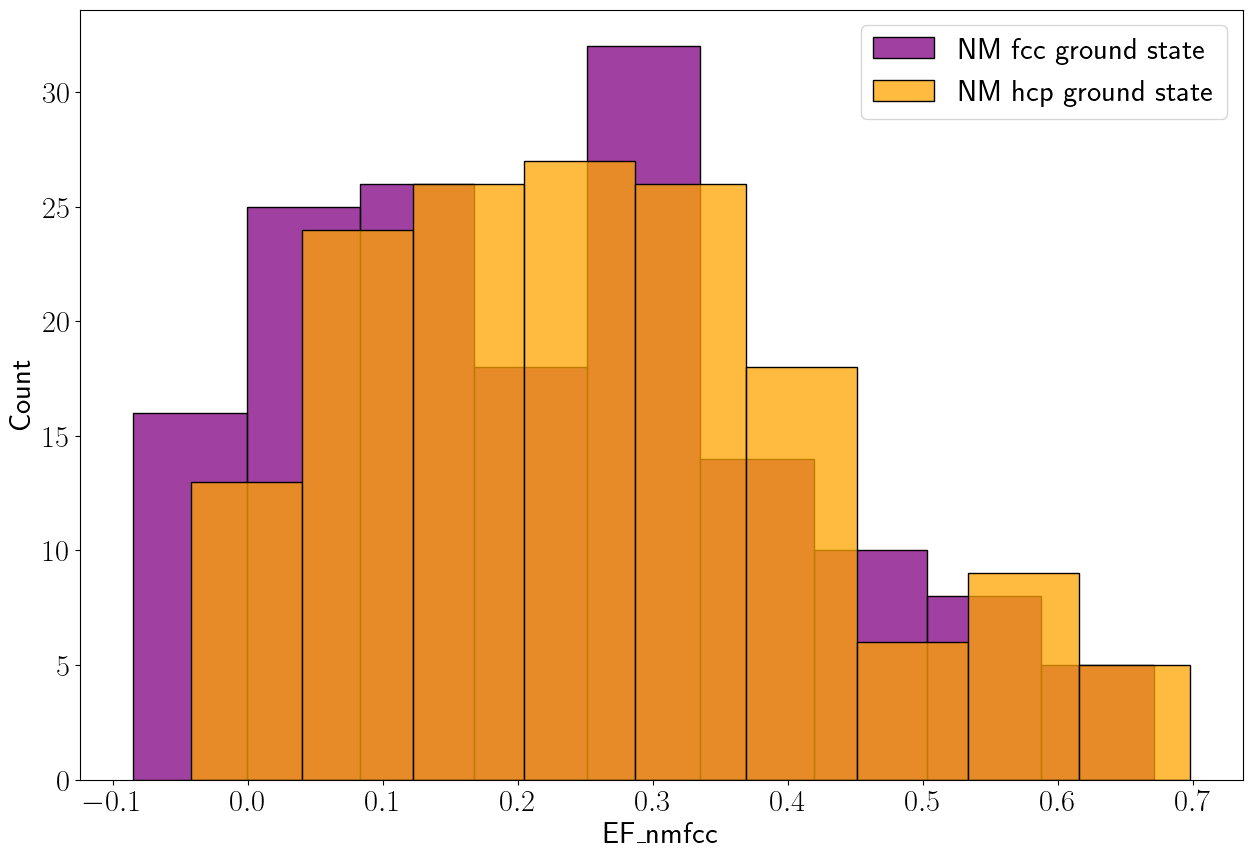

In [38]:
ax = sns.histplot(BS[BS.index.str.contains('NM$')]['EF_nmfcc'], color = 'purple', label = "NM fcc ground state")
ax = sns.histplot(BS[BS.index.str.contains('NM$')]['EF_nmhcp'], color='orange', label ='NM hcp ground state')
ax.legend()

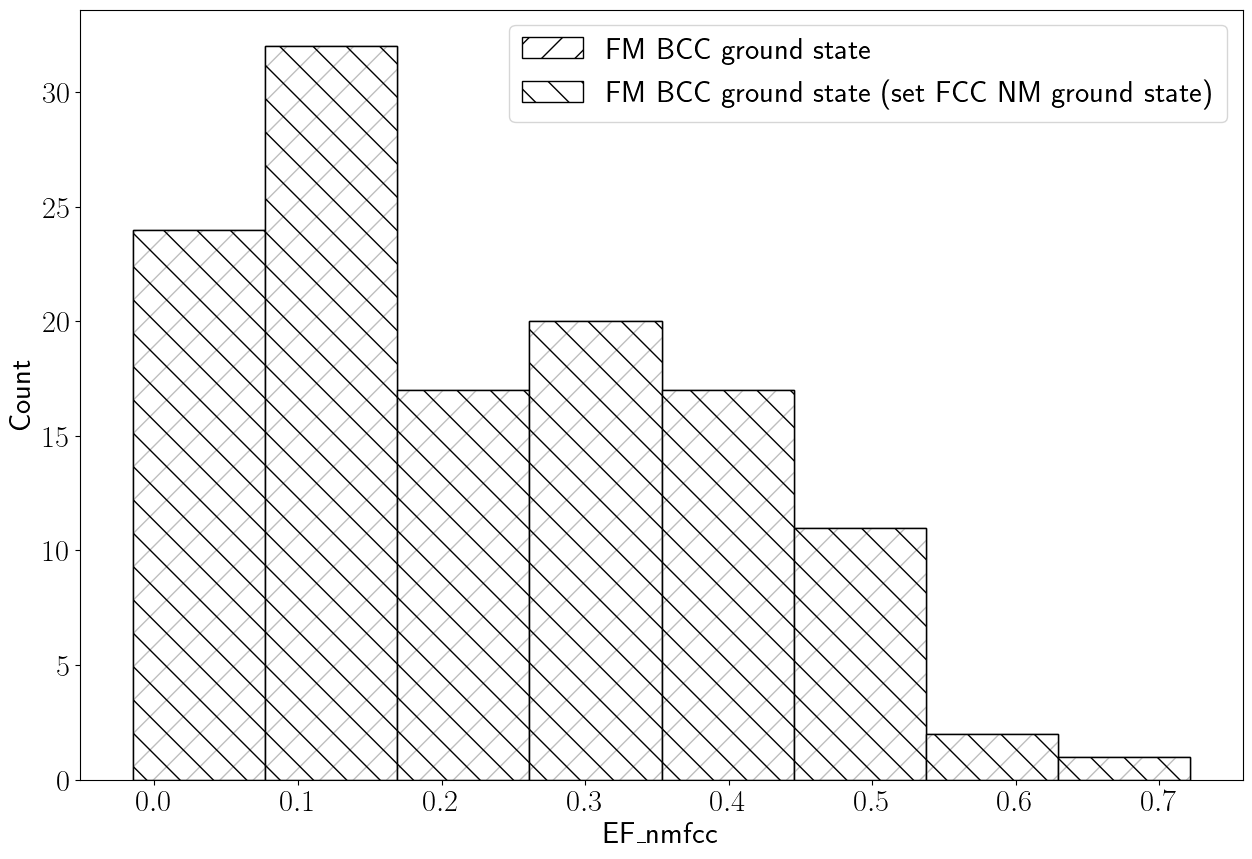

In [39]:
ax = sns.histplot(BS[BS.index.str.contains('FM$')]['EF_nmfcc'], color='white', hatch='/',  label = "FM BCC ground state")
ax = sns.histplot(BS[BS.index.str.contains('FM$')]['EF_nmfcc'], color='white', hatch='\\', label= "FM BCC ground state (set FCC NM ground state)")
ax.legend()


In [40]:
EFNMhcp

Fe_pv4Mo_sv8.C14-ABB        0.697787
Fe_pv2Mo_sv4.C15-AB2        0.673286
Fe_pv8Mo_sv16.C36-AABBB     0.690375
Fe_pv14Mo_sv10.C36-AABAB    0.656999
Fe_pv4Mo_sv9.mu-BBAAB       0.640848
                              ...   
Fe_pv25Mo_sv4.chi-ABAA      0.057857
Fe_pv16Mo_sv8.C36-BBAAA    -0.016932
Fe_pv8Mo_sv4.C14-BAA       -0.032294
Fe_pv4.fcc-cubic            0.079070
Fe_pv2.hcp                  0.000000
Name: EF_nmhcp, Length: 154, dtype: float64

Text(0.0, 0.43273559999999917, 'Fe_pv1.bcc')

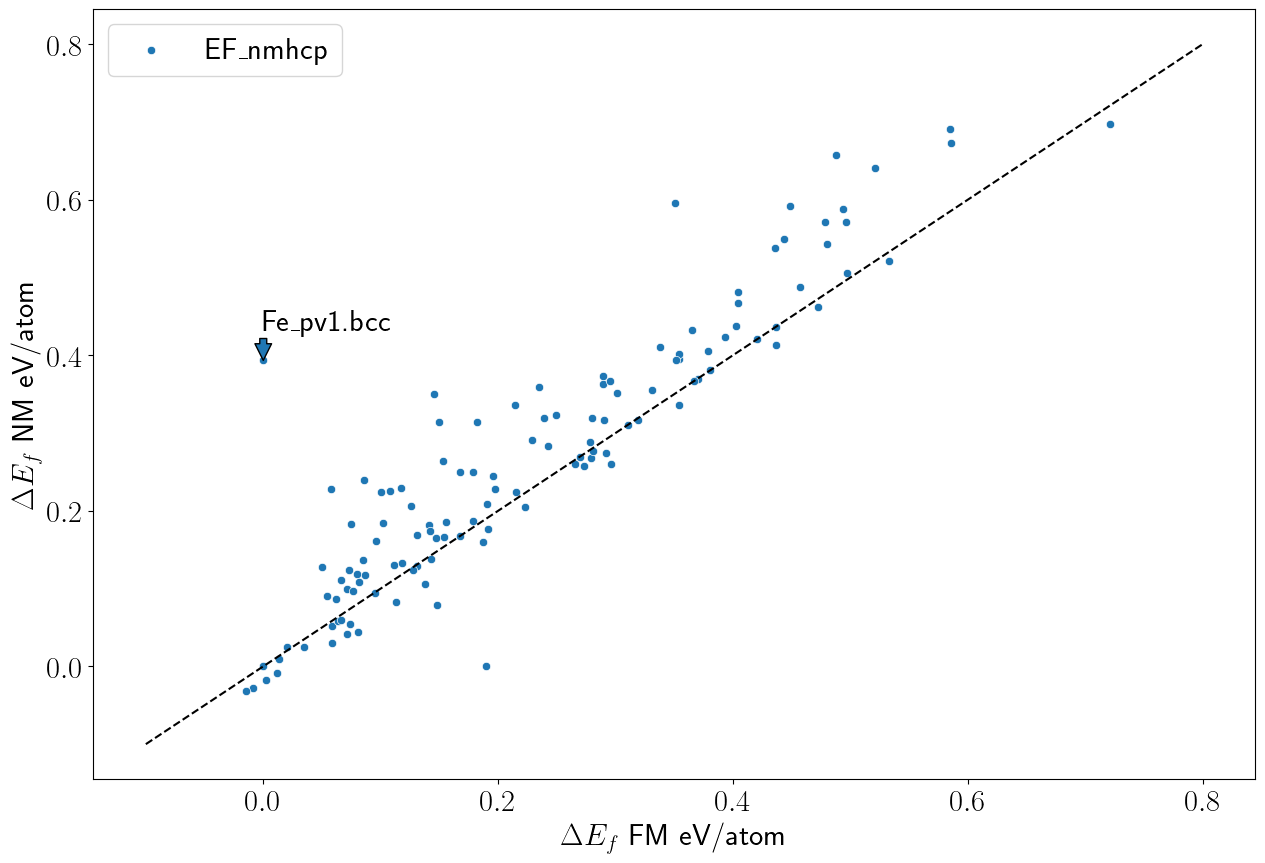

In [41]:
x = [-0.1, 0.8] 
y = [-0.1, 0.8]
ax  = sns.scatterplot(EFFM, EFNMhcp, label=target_case)
ax  = sns.scatterplot(EFFM, EFNMfcc, label='EF_nmhcp', ax=ax, color='purple', size = 20)
ax.plot(x,y, '--k')
ax.set_xlabel(r'$\Delta E _f $ FM  eV/atom')
ax.set_ylabel(r'$\Delta E _f $ NM  eV/atom ')
big_difference = DE_mag[DE_mag>0.3].index[0]
xy = (EFFM[big_difference], EFNMhcp[big_difference])
xytext = (EFFM[big_difference],  EFNMhcp[big_difference]*1.1)
ax.annotate(big_difference, xy , xytext = xytext, arrowprops={'width': 5, })

In [42]:
BIGDIF_FM = BS.filter(regex='E0|atom_').loc[big_difference+'.FM']

In [43]:
BIGDIF_NM = BS.filter(regex='E0|atom_').loc[big_difference+'.NM']

In [44]:
pd.concat([BIGDIF_FM, BIGDIF_NM], axis = 1)

,Fe_pv1.bcc.FM,Fe_pv1.bcc.NM
E0,-8.255294,-7.790673
atom_A,Fe_pv,Fe_pv
atom_B,,
num_atom_A,1,1
num_atom_B,0,0


In [45]:
Features.get_ground_states_energies()

{('Fe_pv', 'FM', 'bcc'): -8.255294,
 ('Fe_pv', 'NM', 'hcp'): -8.184069,
 ('Mo_sv', 'FM', 'bcc'): -10.934251,
 ('Mo_sv', 'NM', 'bcc'): -10.934283}

In [46]:
EREF_FM = BS[BS.index.str.contains('FM$', regex=True) & (BS['nelem'] == 1) & (BS['atom_A'] == 'Fe_pv') ][['E0']].sort_values(by='E0').iloc[0]

In [47]:
EREF_FM

E0   -8.255294
Name: Fe_pv1.bcc.FM, dtype: float64

In [48]:
BIGDIF_FM['E0'] - EREF_FM['E0']

0.0

In [49]:
EREF_NM = BS[BS.index.str.contains('NM$', regex=True) & (BS['nelem'] == 1) & (BS['atom_A'] == 'Fe_pv') ][['E0', 'num_atom_A', 'num_atoms']].sort_values(by='E0').iloc[0]

In [50]:
EREF_NM

E0           -8.184069
num_atom_A    2.000000
num_atoms     2.000000
Name: Fe_pv2.hcp.NM, dtype: float64

In [51]:
BIGDIF_NM['E0'] - EREF_NM['E0']

0.3933959999999992

In [52]:
BS.columns

Index(['', 'V', 'E0', 'B', 'fit', 'xc', 'encut', 'deltak', 'ncrash', 'nelem',
       'B0', 'V0', 'atom_A', 'atom_B', 'num_atom_A', 'num_atom_B', 'num_atoms',
       'Fe_pv', 'Mo_sv', 'EF_nmhcp', 'EF_nmfcc', 'EF_fmbcc', 'Phase'],
      dtype='object')

# convex hulls (binaries only)

In [53]:
from Tools.DatasetTools.Tools import Plotting
P = Plotting()

In [54]:
from importlib.machinery import SourceFileLoader
P = SourceFileLoader('Plotting', 'Tools/DatasetTools/Tools.py').load_module().Plotting()

In [55]:
PhaseBS = {}
verts = {}
chulls = {}
phasepoints = {}

PhaseBS = {phase: BS[BS.Phase == phase] for phase in BS.Phase.unique()}

In [56]:
points = P.get_x_ef_points(PhaseBS, components, property=target_case)
chulls = P.get_convex_hulls(PhaseBS, components, return_points = False, getproperty = target_case)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


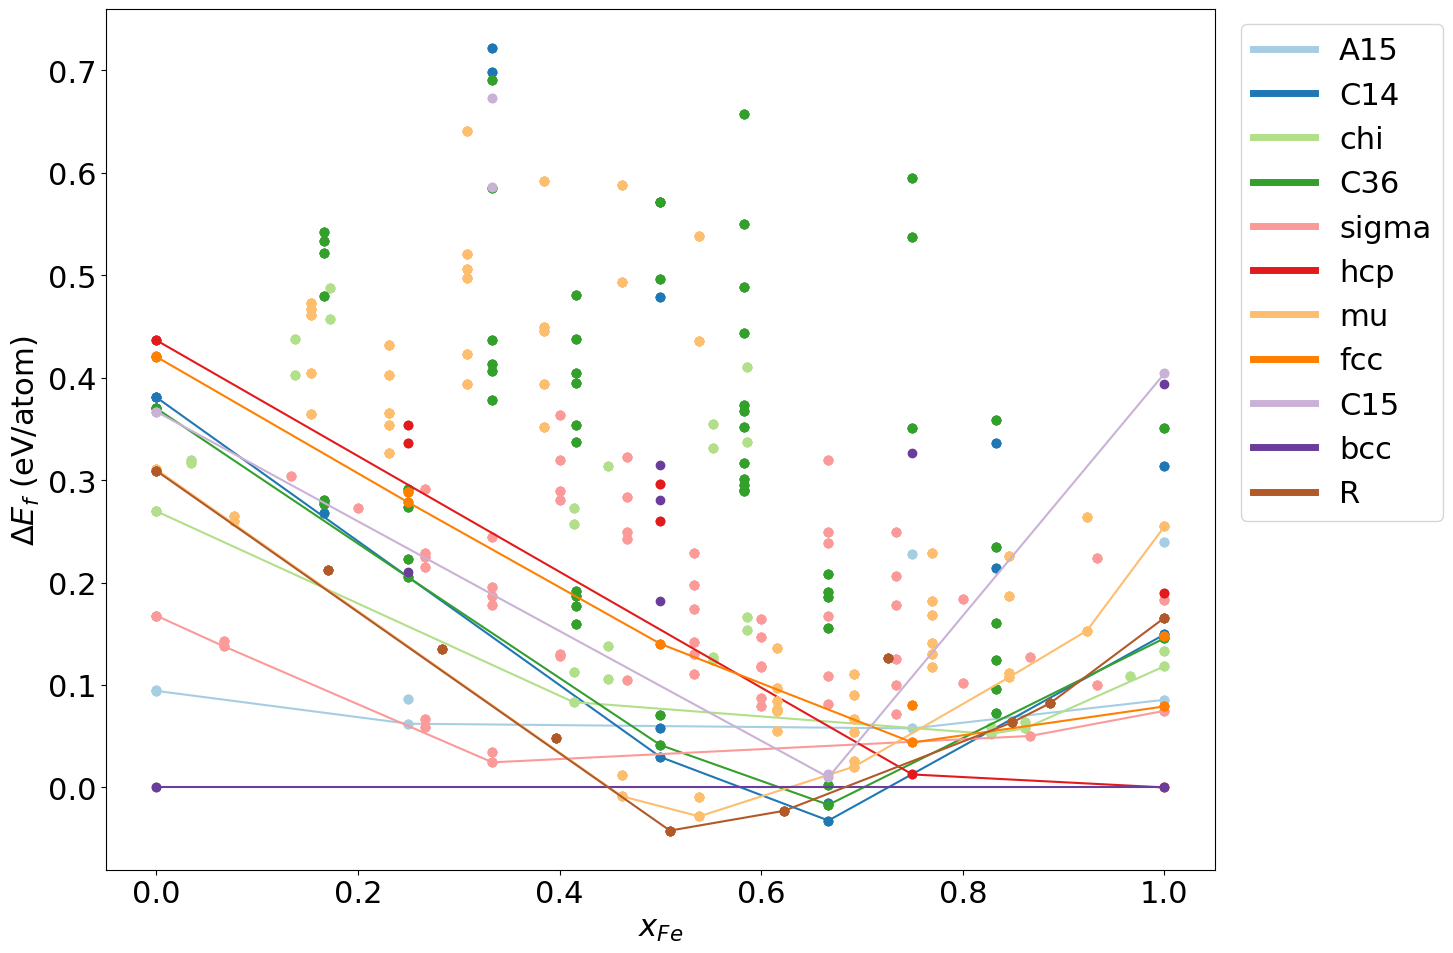

In [57]:
pallette = sns.color_palette("Paired", n_colors=len(PhaseBS)+1)
pallette.pop(-2)
colors = {phase: color for phase, color in zip(PhaseBS.keys(), pallette)}
fig, ax = plt.subplots()
labels=[]
handles = []
for phase, chull in chulls.items():
    for visible_facet in chull.simplices[chull.good]:
        ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
        l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1], color=colors[phase])
    handles.append(l[0])
    labels.append(phase)
leg = ax.legend(handles, labels, bbox_to_anchor=(1.01,1))
setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
ax.set_xlabel(rf'$x_{{{components[0]}}}$')
fig.tight_layout()
fig.savefig(os.path.join(dataset, 'graphs',f'{dataset}_ConvxHulls.eps' ))

In [58]:
BS.to_pickle(os.path.join(dataset, f'FurtherCuratedParsedBriefSummary.pkl'))